<a href="https://colab.research.google.com/github/Rneupane0056/MADS-Course-Work/blob/main/seven_bridges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install networkx matplotlib

In [4]:
import networkx as nx
# one of the most common python packages for graph visualizations
import matplotlib.pyplot as plt

# Step 1: Create an undirected graph
G = nx.MultiGraph()

# Step 2: Add nodes representing the landmasses (A, B, C, D)
G.add_nodes_from(["A", "B", "C", "D"])

# Step 3: Add edges representing the bridges
# Two bridges between A and B
G.add_edge("A", "B")
G.add_edge("A", "B")
# Two bridge between A and C
G.add_edge("A", "C")
G.add_edge("B", "C")

# One bridge between A and D
G.add_edge("A", "D")

# One bridge between B and D
G.add_edge("B", "D")

# One bridge between C and D
G.add_edge("C", "D")

# Step 4: Check the degree of each node
# Print each node and its degree (number of bridges)
for node, degree in G.degree():
    print(f"Landmass {node} has degree {degree}")

# Step 5: Check for an Eulerian path
# For an Eulerian path to exist, the graph must have exactly 0 or 2 nodes with an odd degree
odd_degree_nodes = [node for node, degree in G.degree() if degree % 2 != 0]
num_odd = len(odd_degree_nodes)

if num_odd == 0:
    print("The graph has an Eulerian circuit (start and end at the same node).")
elif num_odd == 2:
    print("The graph has an Eulerian path (start and end at different nodes).")
else:
    print("The graph has neither an Eulerian path nor an Eulerian circuit. The Königsberg Bridge Problem is unsolvable.")


Landmass A has degree 4
Landmass B has degree 4
Landmass C has degree 3
Landmass D has degree 3
The graph has an Eulerian path (start and end at different nodes).


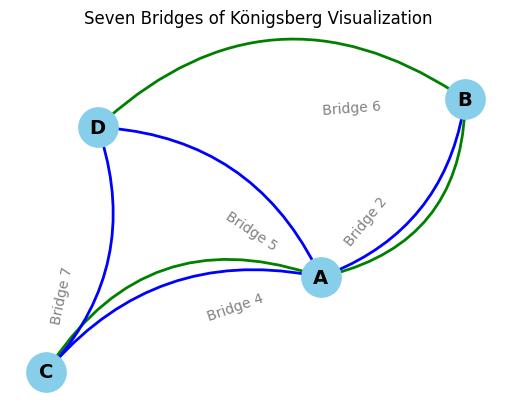

In [3]:
# Define layout for better visualization
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=800, node_color="skyblue")

# Draw edges with different styles for multiple edges
# Collect edges into a list to differentiate curves
edges = list(G.edges(keys=True))
for i, (u, v, k) in enumerate(edges):
    # Assign a curve based on the edge index (more edges = more curve)
    rad = 0.3 + 0.1 * (i % 2)  # Adjust radius for curvature
    color = "blue" if i % 2 == 0 else "green"  # Alternate colors for visibility
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], connectionstyle=f"arc3,rad={rad}", edge_color=color, width=2)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=14, font_color="black", font_weight="bold")

# Optional: Draw edge labels (bridge numbers for clarity)
edge_labels = {(u, v): f"Bridge {i+1}" for i, (u, v, k) in enumerate(edges)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color="gray", label_pos=0.3)

# Show the graph
plt.title("Seven Bridges of Königsberg Visualization")
plt.axis("off")  # Hide axis
plt.show()